In [1]:
!pip install networkx matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.5 MB 5.6 MB/s eta 0:00:03
   ------- -------------------------------- 2.9/15.5 MB 8.0 MB/s eta 0:00:02
   ---------------- ----------------------- 6.6/15.5 MB 13.4 MB/s eta 0:00:01
   ------------------------------ --------- 11.8/15.5 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 16.0 MB/s  0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras 3.8.0 requires ml-dtypes, which is not installed.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, which is not installed.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
edges = pd.read_csv("datasets/elliptic_txs_edgelist.csv")

features = pd.read_csv(
    "datasets/elliptic_txs_features.csv",
    header=None
)

classes = pd.read_csv("datasets/elliptic_txs_classes.csv")

In [4]:
print(edges.shape)
print(features.shape)
print(classes.shape)

(234355, 2)
(203769, 167)
(203769, 2)


In [5]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [6]:
G = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2"
)

In [7]:
print("Number of Nodes :", G.number_of_nodes())
print("Number of Edges :", G.number_of_edges())

Number of Nodes : 203769
Number of Edges : 234355


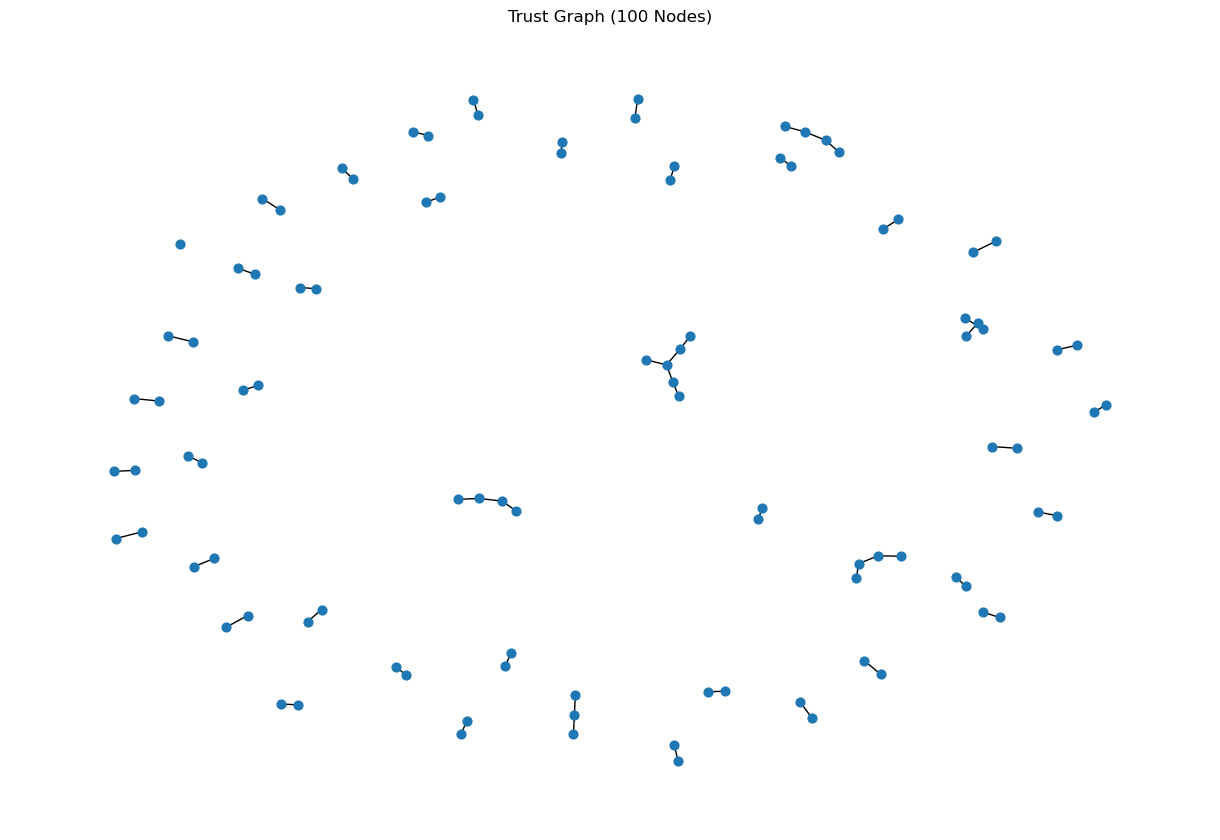

In [8]:
small_graph = G.subgraph(list(G.nodes())[:100])

plt.figure(figsize=(12,8))

nx.draw(
    small_graph,
    node_size=40,
    with_labels=False
)

plt.title("Trust Graph (100 Nodes)")
plt.show()

In [9]:
degree = dict(G.degree())

degree_list = sorted(
    degree.items(),
    key=lambda x: x[1],
    reverse=True
)

degree_list[:10]

[(2984918, 473),
 (89273, 289),
 (43388675, 284),
 (68705820, 247),
 (30699343, 241),
 (96576418, 239),
 (225859042, 212),
 (279187194, 211),
 (234890810, 199),
 (196107869, 188)]

In [10]:
print("Average Degree:",
      sum(dict(G.degree()).values())/G.number_of_nodes())

print("Density:",
      nx.density(G))

Average Degree: 2.3002026804862368
Density: 1.1288341056918834e-05


In [11]:
import pickle

with open("trust_graph.pkl", "wb") as f:
    pickle.dump(G, f)

print("Trust Graph Saved Successfully!")

Trust Graph Saved Successfully!
